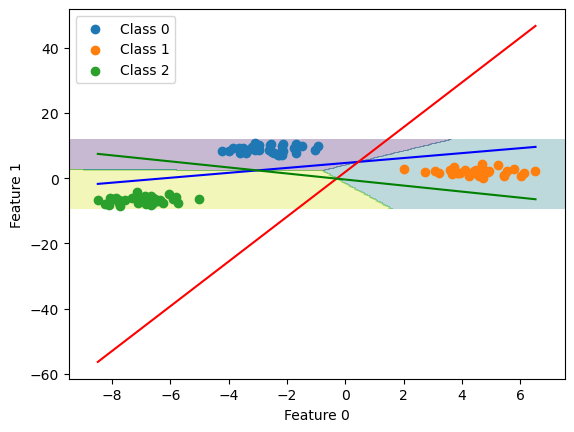

In [52]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.datasets import make_blobs

# Create dataset
X, y = make_blobs(centers=3, random_state=42)

# Train model
linear_svm = LinearSVC(max_iter=10000)
linear_svm.fit(X, y)

# Create mesh grid for background classification
xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 200),
    np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 200)
)

Z = linear_svm.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot classification regions (replacement for plot_2d_classification)
plt.contourf(xx, yy, Z, alpha=0.3)

# Plot data points (replacement for discrete_scatter)
for i in range(3):
    plt.scatter(X[y == i, 0], X[y == i, 1], label=f"Class {i}")

# Plot decision lines
line = np.linspace(X[:, 0].min(), X[:, 0].max(), 100)
for coef, intercept, color in zip(linear_svm.coef_, linear_svm.intercept_, ['b', 'r', 'g']):
    plt.plot(line, -(coef[0]*line + intercept)/coef[1], c=color)

# Labels
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend()
plt.show()